About Dataset 


🔹 This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases.


🔹 The objective is to predict based on diagnostic measurements whether a patient has diabetes.


# Diabetes Dataset Features

| Feature | Description |
|---------|-------------|
| Number of times pregnant | Count of pregnancies |
| Plasma glucose concentration | Measured 2 hours after an oral glucose tolerance test |
| Diastolic blood pressure (mm Hg) | Blood pressure reading |
| Triceps skin fold thickness (mm) | Thickness measurement of triceps skin fold |
| 2-Hour serum insulin (mu U/ml) | Serum insulin level after 2 hours |
| Body mass index (BMI) | Weight in kg / (height in m)^2 |
| Diabetes pedigree function | A function that scores likelihood of diabetes based on family history |
| Age (years) | Age of the individual |
| Class variable | 0 = Non-diabetic, 1 = Diabetic |

## Import needed libraries

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

#Data manioulation
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

#Data vizualisation
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## 1.Load the dataset

In [5]:
file_path = r'E:\Z_Arise\DAHC\Ex_1\diabetes.csv'

data = pd.read_csv(file_path)
print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


## 2.Explore the dataset

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


#### 

| Feature | Description |
|---------|-------------|
| Pregnancies                | Count of pregnancies |
| Plasma glucose concentration | Measured 2 hours after an oral glucose tolerance test |
| Diastolic blood pressure (mm Hg) | Blood pressure reading |
| Triceps skin fold thickness (mm) | Thickness measurement of triceps skin fold |
| 2-Hour serum insulin (mu U/ml) | Serum insulin level after 2 hours |
| Body mass index (BMI) | Weight in kg / (height in m)^2 |
| Diabetes pedigree function | A function that scores likelihood of diabetes based on family history |
| Age (years) | Age of the individual |
| Class variable | 0 = Non-diabetic, 1 = Diabetic |

In [7]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [10]:
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


### Search for any misiing data

In [13]:
data.isnull()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False


In [14]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

This is perfect. We have not any missing values :))

# Key Points on Missing Data

- There are **no missing values (NaN)** in this dataset.  
- However, some features contain **zero values** that are physiologically implausible:  
  - `Glucose = 0`  
  - `BloodPressure = 0`  
  - `BMI = 0`  
- These zeros are often treated as **missing data** and replaced using imputation strategies such as:  
  - Mean substitution  
  - Median substitution  
  - Regression-based filling  

# Explanation of Data Types

- **int64** → Whole numbers (e.g., counts, measurements without decimals)  
- **float64** → Decimal values (e.g., BMI, diabetes pedigree function)  
- **Outcome** → Binary class label  
  - `0` = Non-diabetic  
  - `1` = Diabetic  

In [15]:
data.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

# 3.Data Visualization

#### Basic Visualizations for Diabetes Dataset

### 1. Distribution of Outcome
- Bar plot of `Outcome` (0 = Non-diabetic, 1 = Diabetic)  
- Helps understand class balance (imbalanced datasets may need resampling).

### 2. Age Distribution
- Histogram of `Age`  
- Shows how age is spread across the dataset and whether diabetes prevalence increases with age.

### 3. Pregnancies vs Outcome
- Boxplot or violin plot of `Pregnancies` grouped by `Outcome`  
- Reveals whether number of pregnancies is linked to diabetes risk.

### 4. Glucose Levels
- Histogram or KDE plot of `Glucose`  
- Compare distributions for diabetic vs non-diabetic groups.

### 5. BMI Distribution
- Histogram of `BMI`  
- Important since obesity is a strong risk factor for diabetes.

### 6. Correlation Heatmap
- Heatmap of correlations between all features  
- Identifies which variables are most strongly associated with diabetes.

### 7. Pairplots (Scatter Matrix)
- Pairplot of selected features (e.g., `Glucose`, `BMI`, `Age`, `Insulin`)  
- Helps visualize relationships and separability between classes.

### 8. Boxplots for Outliers
- Boxplots of continuous variables (`Glucose`, `BloodPressure`, `BMI`, etc.)  
- Detects extreme values and potential data quality issues.

### 9. Diabetes Pedigree Function
- Histogram of `DiabetesPedigreeFunction`  
- Shows how family history scores differ between diabetic and non-diabetic individuals.

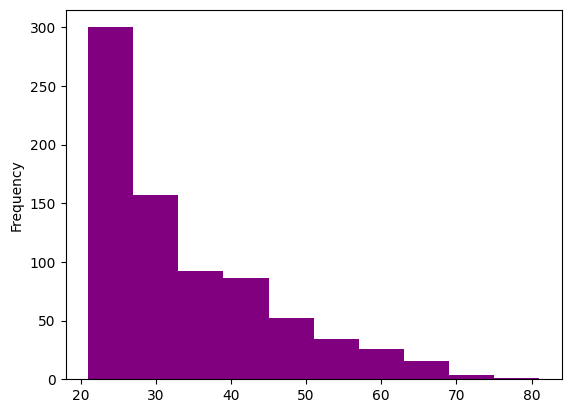

In [18]:
data.Age.plot(color='purple',kind='hist') #Histogram
plt.show()

### 1. Distribution of Outcome (Class Balance)

C:\Users\admin\AppData\Local\Temp\ipykernel_10836\3712766540.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=data, palette='Set2')


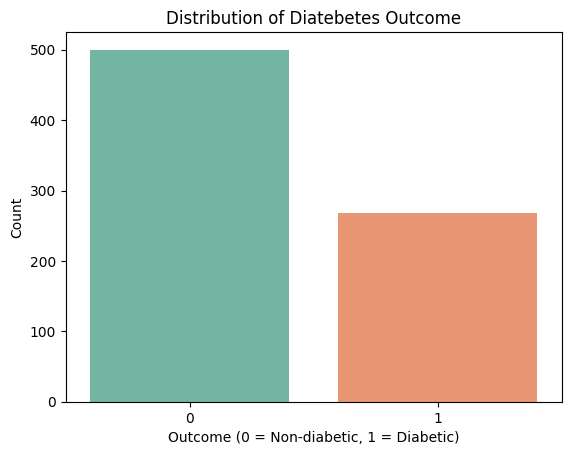

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
#countplot for Outcome

sns.countplot(x='Outcome', data=data, palette='Set2')
plt.title("Distribution of Diatebetes Outcome")
plt.xlabel('Outcome (0 = Non-diabetic, 1 = Diabetic)')
plt.ylabel('Count')
plt.show()

#### Explanation:
##### This shows how many people are diabetic vs non-diabetic. If the dataset is imbalanced (e.g., far more 0s than 1s), you may need techniques like oversampling or class weighting.


### 2. Age Distribution





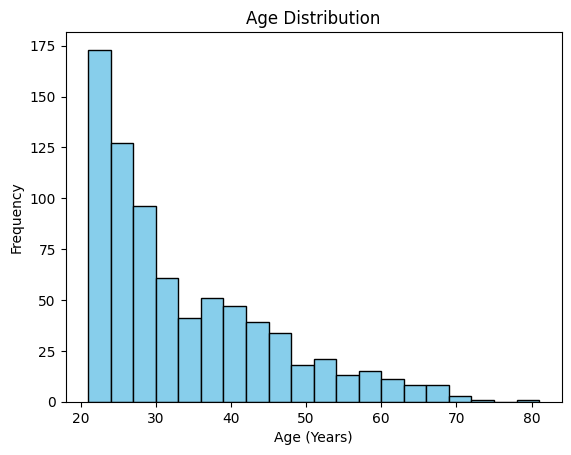

In [22]:
plt.hist(data['Age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel("Age (Years)")
plt.ylabel("Frequency")
plt.show()

#### Explanation:
##### This histogram shows the age spread. You can check if diabetes is more common in older individuals by later grouping by Outcome.


### 3. Pregnancies vs Outcome

C:\Users\admin\AppData\Local\Temp\ipykernel_10836\4222213499.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Pregnancies', data=data, palette='Set3')


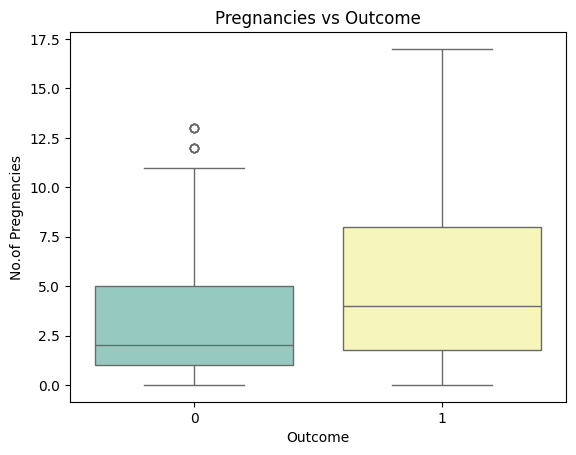

In [24]:
sns.boxplot(x='Outcome', y='Pregnancies', data=data, palette='Set3')
plt.title("Pregnancies vs Outcome")
plt.xlabel("Outcome")
plt.ylabel("No.of Pregnencies")
plt.show()

#### Explanation:
##### Boxplots reveal whether higher pregnancy counts are associated with diabetes. You’ll see the median and spread for each group.




### 4.Glucose levels

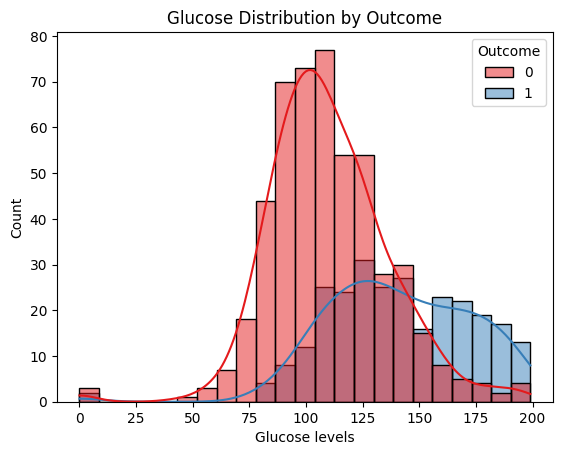

In [25]:
sns.histplot(data=data, x='Glucose', hue='Outcome', kde=True,palette='Set1')
plt.title('Glucose Distribution by Outcome')
plt.xlabel('Glucose levels')
plt.ylabel('Count')
plt.show()

#### Explanation:
##### This compares glucose distributions for diabetic vs non-diabetic individuals. Diabetic patients usually have higher glucose values.


### 5.BMI Distribution

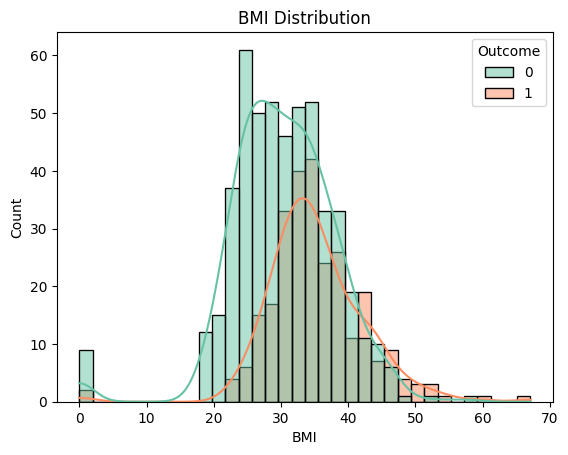

In [26]:
sns.histplot(data=data, x='BMI', hue='Outcome', kde=True, palette='Set2')
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

#### Explanation:
##### Obesity is a strong risk factor. This plot shows how BMI differs between diabetic and non-diabetic groups.


### 6.Correlation Heatmap

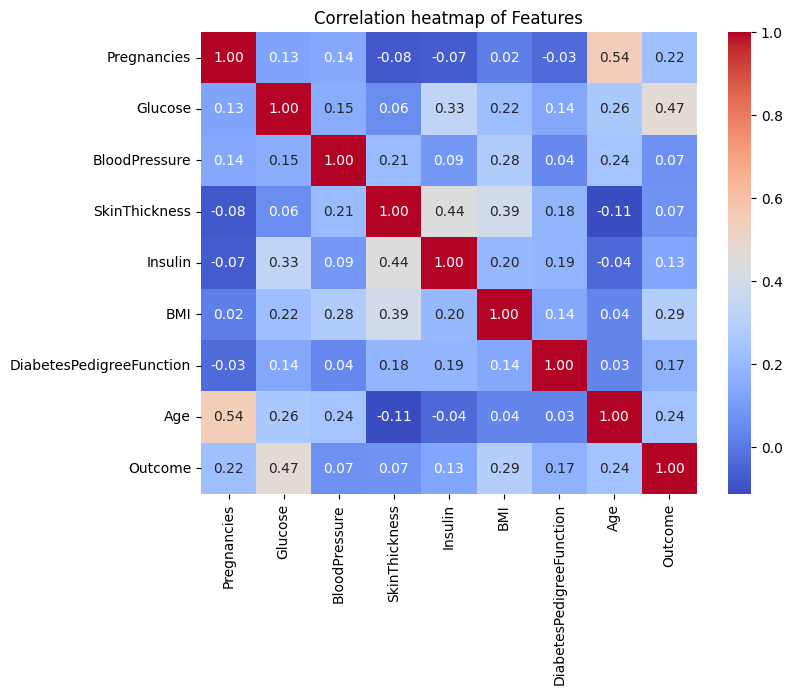

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(),annot=True, cmap='coolwarm',fmt='.2f')
plt.title("Correlation heatmap of Features")
plt.show()

#### Explanation:
##### This heatmap shows correlations between features. For example, Glucose often has the strongest correlation with Outcome.


### 7. Pairplots (Scatter Matrix)

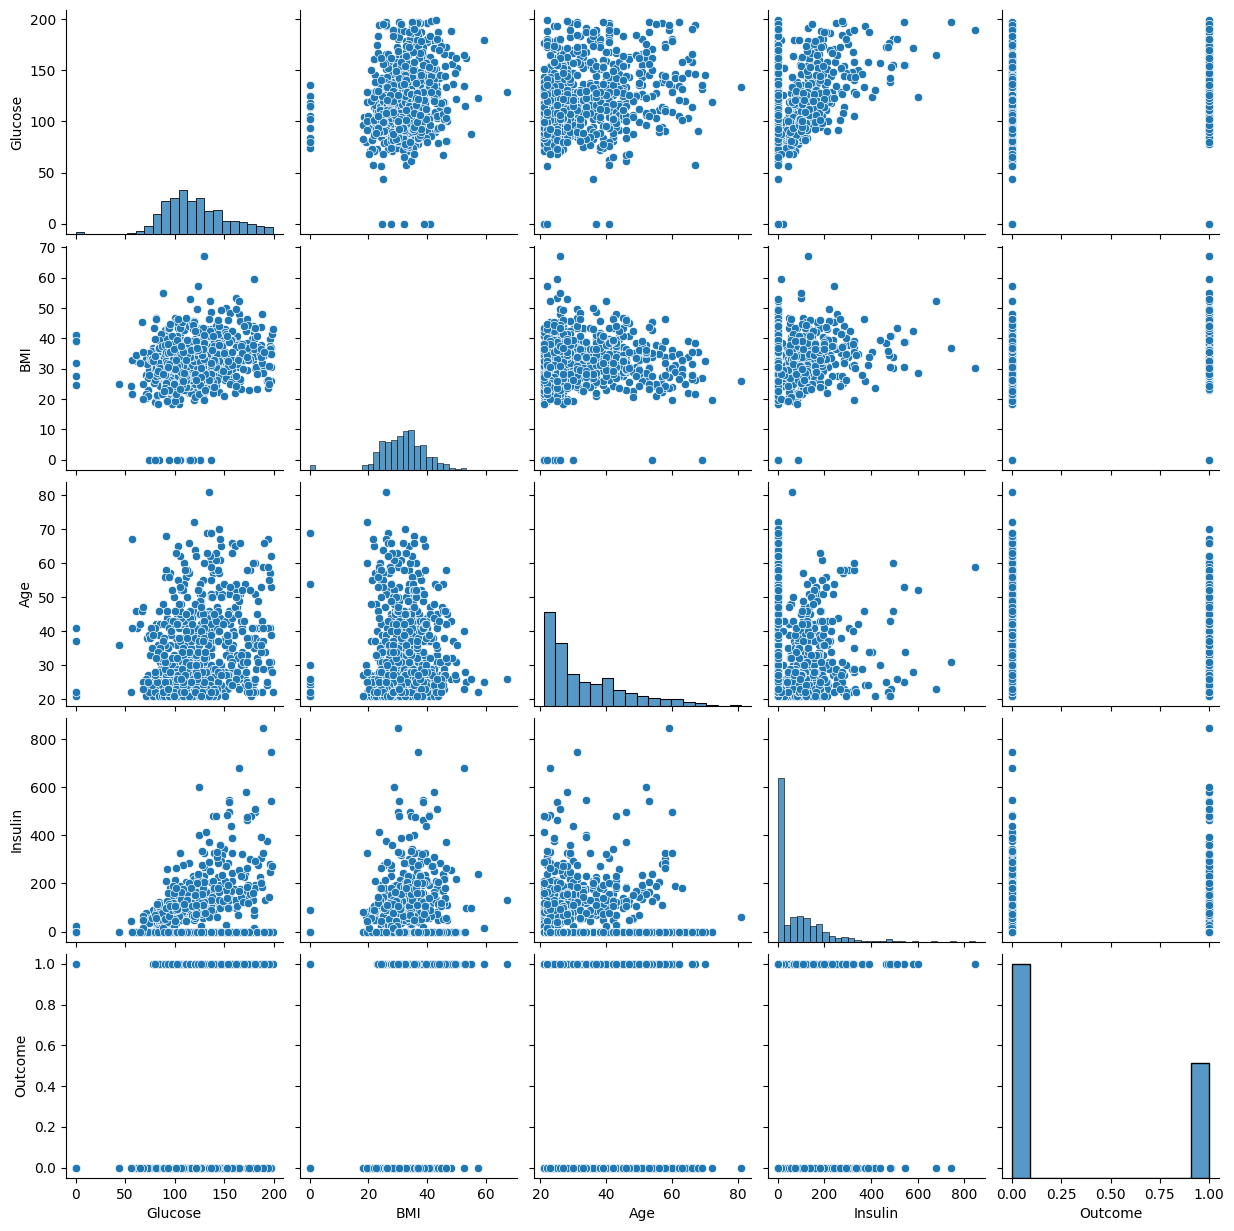

In [37]:
sns.pairplot(data[['Glucose','BMI','Age','Insulin','Outcome']])
plt.show()

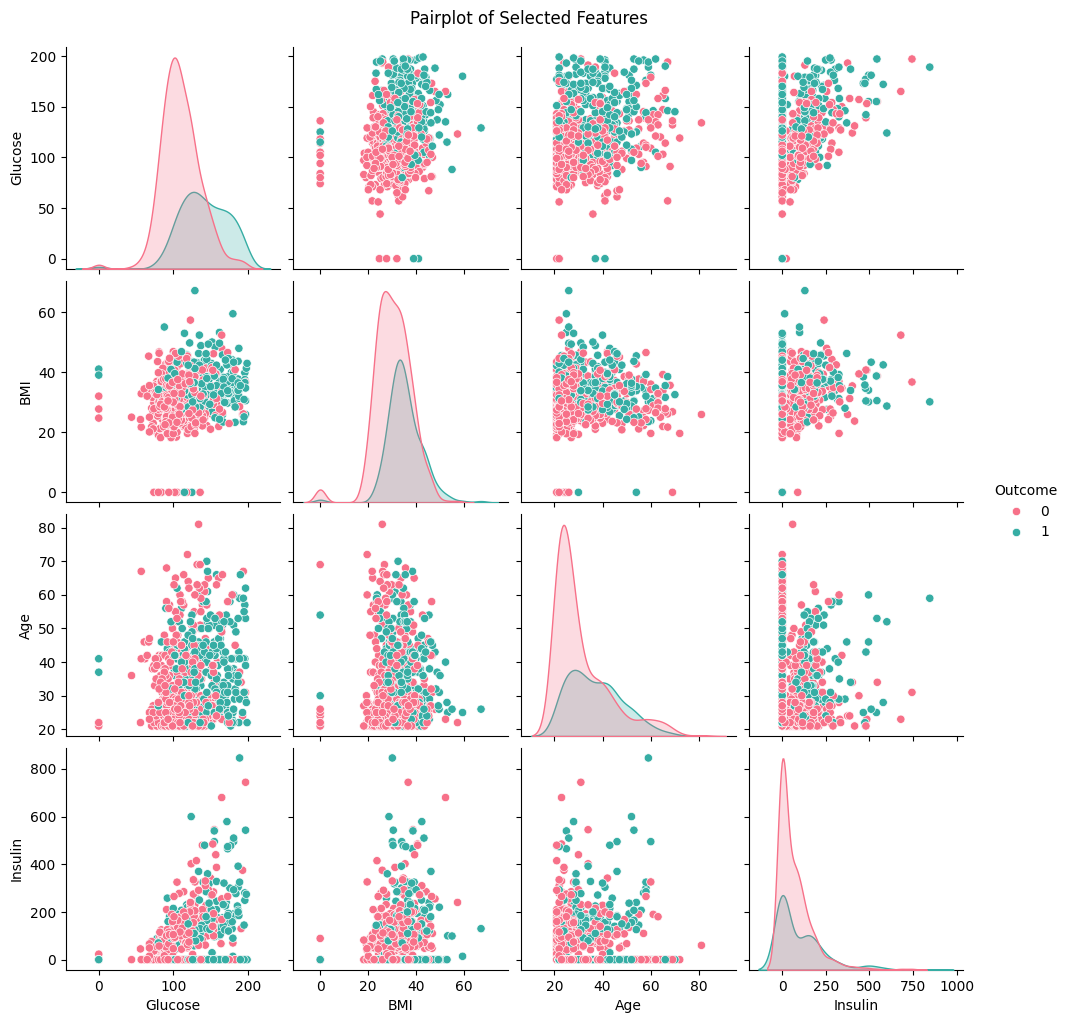

In [49]:
# Selected features: Glucose, BMI, Age, Insulin
# plt.figure(figsize=(8,6))
sns.pairplot(data[["Glucose", "BMI", "Age", "Insulin", "Outcome"]], 
             hue="Outcome", 
             diag_kind="kde", 
             palette="husl")
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()



### 8.Box plot for outliers

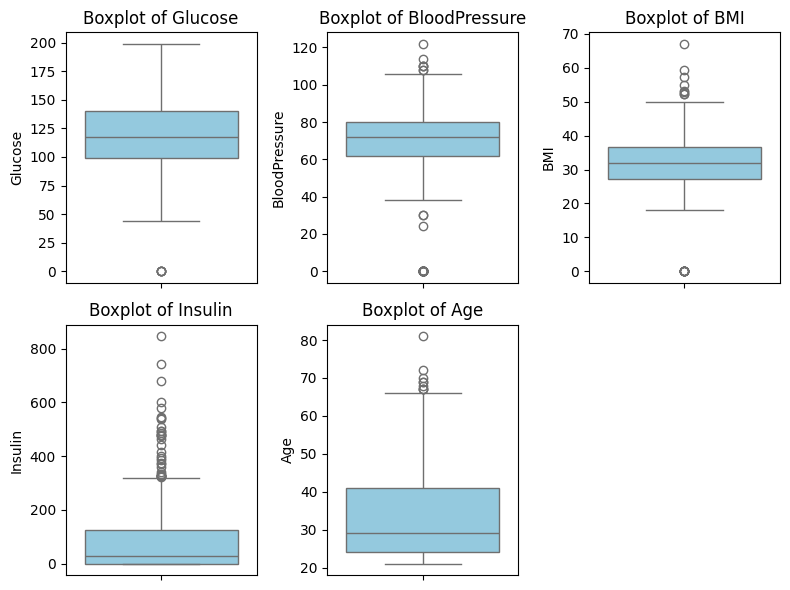

In [44]:
# Continuous variables: Glucose, BloodPressure, BMI, etc.
continuous_vars = ["Glucose", "BloodPressure", "BMI", "Insulin", "Age"]

plt.figure(figsize=(8, 6))
for i, col in enumerate(continuous_vars, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col], color="skyblue")
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()



### 9.Diabetes Pedigree Function

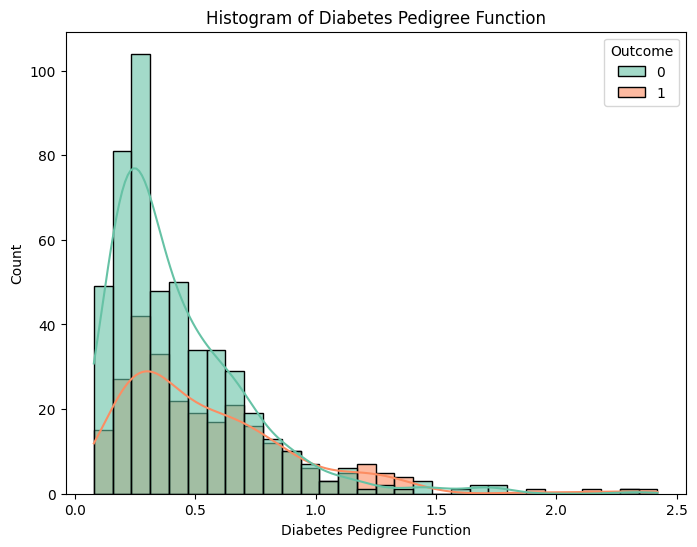

In [46]:
plt.figure(figsize=(8, 6))
sns.histplot(data=data, x="DiabetesPedigreeFunction", hue="Outcome", 
             bins=30, kde=True, palette="Set2", alpha=0.6)
plt.title("Histogram of Diabetes Pedigree Function")
plt.xlabel("Diabetes Pedigree Function")
plt.ylabel("Count")
plt.show()
